## Basic Neural Networks in PyTorch

In [ ]:
! pip install seaborn matplotlib torch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as ReLU
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.w1 = torch.tensor(1.0)
        self.b1 = torch.tensor(-15.0)

        self.w2 = torch.tensor(1.0)
        self.b2 = torch.tensor(-25.0)

        self.w3 = torch.tensor(2.0)
        self.w4 = torch.tensor(-3.0)


    def forward(self, input_values):

        top_x_axis_values = (input_values * self.w1) + self.b1
        bottom_x_axis_values = (input_values * self.w2) + self.b2

        top_y_axis_values = ReLU.relu(top_x_axis_values)
        bottom_y_axis_values = ReLU.relu(bottom_x_axis_values)

        output_values = (top_y_axis_values) * self.w3 + (bottom_y_axis_values) * self.w4

        return output_values
        
    

In [5]:
model = NeuralNetwork()
temps = torch.tensor([10.0, 17.0, 20.0, 22.0, 25.0, 30.0])
model(temps)

tensor([ 0.,  4., 10., 14., 20., 15.])

In [6]:
torch.round(model(temps), decimals = 2)

tensor([ 0.,  4., 10., 14., 20., 15.])

### Plot the Various Stages of the Neural Network

In [8]:
input_temps = torch.linspace(start = 5, end = 35, steps = 20)
input_temps

tensor([ 5.0000,  6.5789,  8.1579,  9.7368, 11.3158, 12.8947, 14.4737, 16.0526,
        17.6316, 19.2105, 20.7895, 22.3684, 23.9474, 25.5263, 27.1053, 28.6842,
        30.2632, 31.8421, 33.4211, 35.0000])

In [10]:
top_x_axis_values = model.w1 * input_temps + model.b1
top_y_axis_values = ReLU.relu(top_x_axis_values)
top_y_axis_values

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0526,
         2.6316,  4.2105,  5.7895,  7.3684,  8.9474, 10.5263, 12.1053, 13.6842,
        15.2632, 16.8421, 18.4211, 20.0000])

Text(0.5, 0, 'Temperatures')

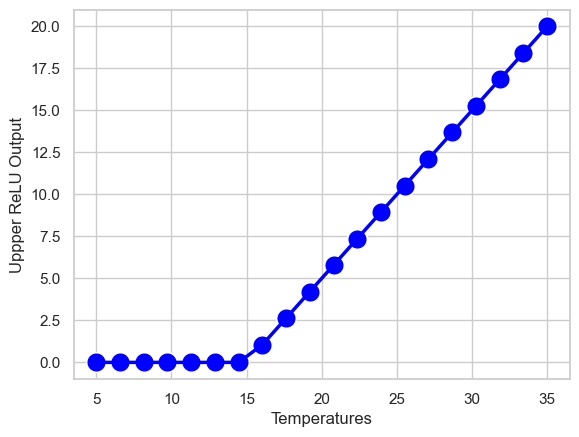

In [13]:
sns.set(style = "whitegrid")
sns.scatterplot(x = input_temps, y = top_y_axis_values, color = 'blue', s = 200)
sns.lineplot(x = input_temps, y = top_y_axis_values, color = 'blue', linewidth = 2.5)

plt.ylabel('Uppper ReLU Output')
plt.xlabel('Temperatures')

Text(0.5, 0, 'Temperatures')

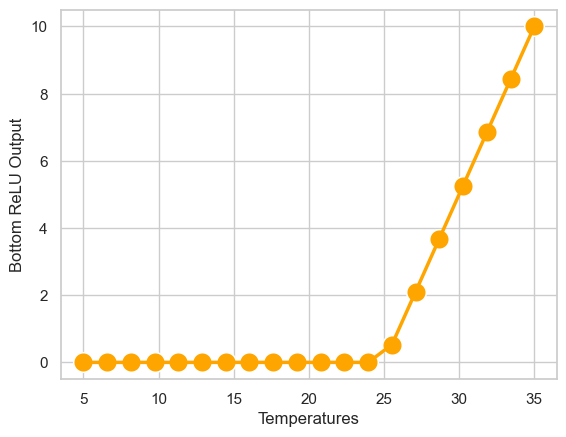

In [19]:
bottom_x_axis_values = model.w2 * input_temps + model.b2
bottom_y_axis_values = ReLU.relu(bottom_x_axis_values)

sns.set(style = "whitegrid")
sns.scatterplot(x = input_temps, y = bottom_y_axis_values, color = 'orange', s = 200)
sns.lineplot(x = input_temps, y = bottom_y_axis_values, color = 'orange', linewidth = 2.5)

plt.ylabel('Bottom ReLU Output')
plt.xlabel('Temperatures')

Text(0.5, 0, 'Temperatures')

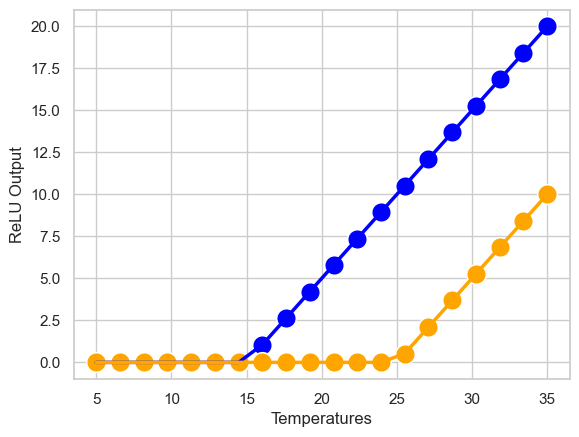

In [20]:
sns.set(style = "whitegrid")
sns.scatterplot(x = input_temps, y = top_y_axis_values, color = 'blue', s = 200)
sns.lineplot(x = input_temps, y = top_y_axis_values, color = 'blue', linewidth = 2.5)


sns.scatterplot(x = input_temps, y = bottom_y_axis_values, color = 'orange', s = 200)
sns.lineplot(x = input_temps, y = bottom_y_axis_values, color = 'orange', linewidth = 2.5)

plt.ylabel('ReLU Output')
plt.xlabel('Temperatures')

### Now stretch those bent shapes by scaling them by the final weights in the neural network

Text(0.5, 0, 'Temperatures')

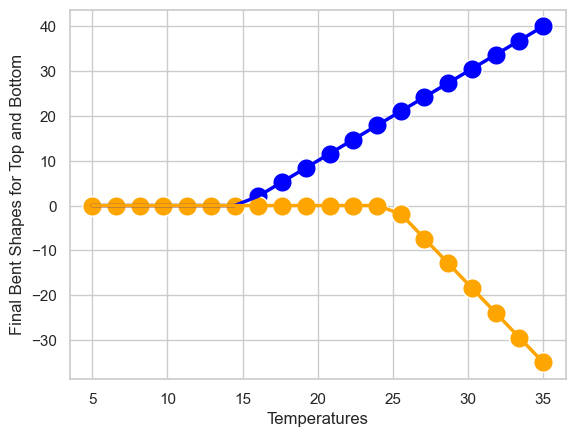

In [29]:
model.w4 = -3.5
final_top_y_axis_values = top_y_axis_values * model.w3
final_bottom_y_axis_values = bottom_y_axis_values * model.w4

sns.set(style = "whitegrid")

sns.scatterplot(x = input_temps, y = final_top_y_axis_values, color = 'blue', s = 200)
sns.lineplot(x = input_temps, y = final_top_y_axis_values, color = 'blue', linewidth = 2.5)


sns.scatterplot(x = input_temps, y = final_bottom_y_axis_values, color = 'orange', s = 200)
sns.lineplot(x = input_temps, y = final_bottom_y_axis_values, color = 'orange', linewidth = 2.5)

plt.ylabel('Final Bent Shapes for Top and Bottom')
plt.xlabel('Temperatures')


tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  2.1053,
         5.2632,  8.4211, 11.5789, 14.7368, 17.8947, 19.2105, 16.8421, 14.4737,
        12.1053,  9.7368,  7.3684,  5.0000])


Text(0.5, 0, 'Dose')

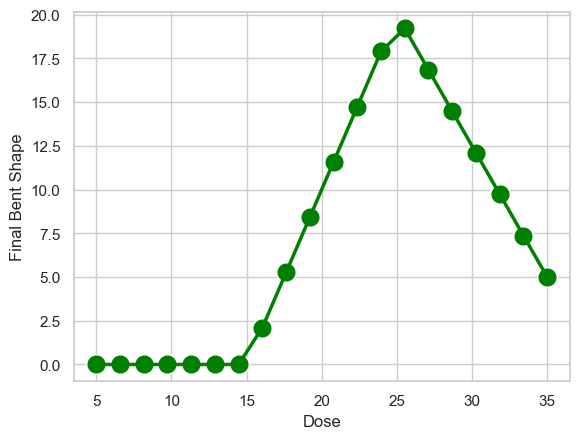

In [31]:
final_bent_shapes = final_top_y_axis_values + final_bottom_y_axis_values
print(final_bent_shapes)
sns.set(style = 'whitegrid')
sns.scatterplot(x = input_temps, y = final_bent_shapes, color = 'green', s = 200)
sns.lineplot(x = input_temps, y = final_bent_shapes, color = 'green', linewidth = 2.5)

plt.ylabel('Final Bent Shape')
plt.xlabel('Dose')

## Build and Train a very simple neural network with backpropagatin

In [2]:
import torch ## torch let's us create tensors and also provides helper functions
import torch.nn as nn ## torch.nn gives us nn.Module(), nn.Embedding() and nn.Linear()
import torch.nn.functional as F # This gives us relu()
from torch.optim import SGD # SGD is short of Stochastic Gradient Descent, but
                            # the way we'll use it, passing in all of the training
                            # data at once instead of passing it random subsets,
                            # it will act just like plain old Gradient Descent.

import lightning as L ## Lightning makes it easier to write, optimize and scale our code
from torch.utils.data import TensorDataset, DataLoader ## We'll store our data in DataLoaders

import matplotlib.pyplot as plt ## matplotlib allows us to draw graphs.
import seaborn as sns ## seaborn makes it easier to draw nice-looking graphs.

### Create the Training Dataset

In [140]:
training_inputs = torch.tensor([10.0, 17.0, 20.0, 22.0, 25.0, 30.0])

training_labels = torch.tensor([ 0.,  4., 10., 14., 20., 15.])

training_dataset = TensorDataset(training_inputs, training_labels)
dataloader = DataLoader(training_dataset)

### Create a NN with Trainable Weights and Biases

In [141]:
class NeuralNetwork(L.LightningModule):
    def __init__(self):
        super().__init__()

        self.w1 = nn.Parameter(torch.tensor(1.0))
        self.b1 = nn.Parameter(torch.tensor(-15.0))
        
        self.w2 = nn.Parameter(torch.tensor(1.0))
        self.b2 = nn.Parameter(torch.tensor(-25.0))

        self.w3 = nn.Parameter(torch.tensor(2.0))
        self.w4 = nn.Parameter(torch.tensor(-2.0))

        self.loss = nn.MSELoss(reduction = 'mean')

    def forward(self, input_values):
        top_x_axis_values = (input_values * self.w1) + self.b1
        bottom_x_axis_values = (input_values * self.w2) + self.b2

        top_y_axis_values = F.relu(top_x_axis_values)
        bottom_y_axis_values = F.relu(bottom_x_axis_values)

        output_values = (top_y_axis_values * self.w3) + (bottom_y_axis_values * self.w4)

        return output_values


    def configure_optimizers(self):
         return torch.optim.Adam(self.parameters(), lr=0.05)


    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self.forward(inputs)
        loss = self.loss(outputs, labels)

        return loss

#### NOTE: I Tried to use SGD but it lead to dead-ReLU Flat Region so i changed it to adam then it got solved and lead to satisfactory prediction

SGD uses the same step size for every parameter, so with ReLU gates it can push the biases into a region where both ReLUs stay off, killing gradients and collapsing outputs to zero. Adam adapts per-parameter learning rates, rescuing small gradients and escaping this dead-ReLU flat region.

Look at one branch:
top_x = input * w1 + b1 and then ReLU(top_x).

With SGD, suppose an update makes b1 a bit more negative. Now for all inputs, top_x < 0. ReLU outputs exactly 0. Gradient through ReLU becomes 0, so w1 and b1 stop updating forever. Same happens to the bottom branch → total output becomes all zeros.

With Adam, when gradients start shrinking, Adam automatically increases the effective step size for those stuck parameters (via moment estimates). That lets b1 move back above zero for some inputs, ReLU reactivates, gradients flow again, and learning resumes.

SGD gets stuck in a dead region. Adam escapes it.

In [142]:
model = NeuralNetwork()
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals = 2))

w1 tensor(1.)
b1 tensor(-15.)
w2 tensor(1.)
b2 tensor(-25.)
w3 tensor(2.)
w4 tensor(-2.)


In [143]:
with torch.no_grad():
    predictions = model(training_inputs)

print(predictions)

tensor([ 0.,  4., 10., 14., 20., 20.])


Text(0.5, 0, 'Temps')

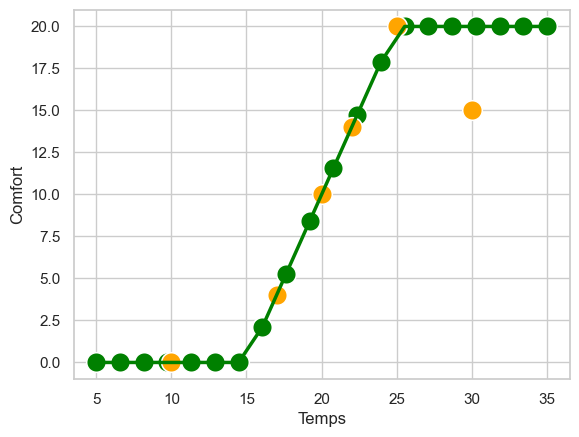

In [144]:
input_temps = torch.linspace(start = 5, end = 35, steps = 20)
output_comfort = model(input_temps)

sns.set(style = "whitegrid")
sns.scatterplot(x = input_temps, y = output_comfort.detach().numpy(), color = 'green', s = 200)

sns.lineplot(x = input_temps, y = output_comfort.detach().numpy(), color = 'green', linewidth = 2.5)

sns.scatterplot(x = training_inputs, y = training_labels, color = 'orange', s = 200)

plt.ylabel('Comfort')
plt.xlabel('Temps')

### Training the Weights and Biases in the Neural Network

In [145]:
model = NeuralNetwork()

trainer = L.Trainer(
    max_epochs=500,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False
)

trainer.fit(model, train_dataloaders=dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type    | Params | Mode  | FLOPs
---------------------------------------------------------
0 | loss         | MSELoss | 0      | train | 0    
  | other params | n/a     | 6      | n/a   | n/a  
---------------------------------------------------------
6         Trainable params
0         Non-trainable params
6         Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
0         Total Flops
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSp

In [146]:
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals = 3))

w1 tensor(1.1460)
b1 tensor(-16.2910)
w2 tensor(1.0600)
b2 tensor(-26.5710)
w3 tensor(1.5670)
w4 tensor(-2.5890)


tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.4744,  3.3107,
         6.1470,  8.9834, 11.8197, 14.6560, 17.4923, 19.0804, 17.5840, 16.0876,
        14.5911, 13.0947, 11.5983, 10.1019], grad_fn=<AddBackward0>)


Text(0.5, 0, 'Temps')

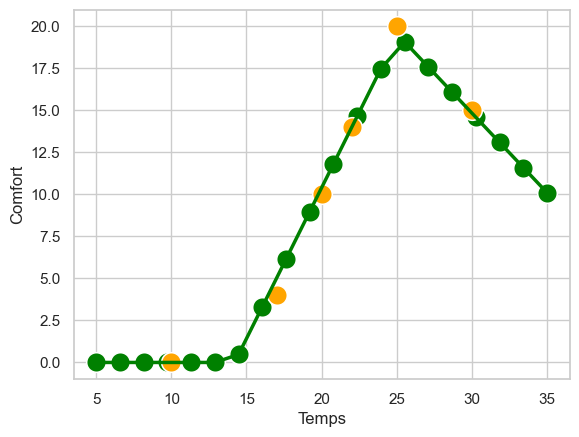

In [147]:
output_comfort = model(input_temps)
print(output_comfort)
sns.set(style = "whitegrid")
sns.scatterplot(x = input_temps, y = output_comfort.detach().numpy(), color = 'green', s = 200)

sns.lineplot(x = input_temps, y = output_comfort.detach().numpy(), color = 'green', linewidth = 2.5)

sns.scatterplot(x = training_inputs, y = training_labels, color = 'orange', s = 200)

plt.ylabel('Comfort')
plt.xlabel('Temps')